In [1]:
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preprocessing data
### Standardization, or mean removal and variance scaling

In [2]:
from sklearn import preprocessing

In [6]:
X_train = np.array(
    [
        [1., -1., 2.],
        [2., 0., 0.],
        [0., 1., -1.]
    ]
)
scaler = preprocessing.StandardScaler().fit(X_train)
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [7]:
scaler.mean_

array([1.        , 0.        , 0.33333333])

In [8]:
scaler.scale_

array([0.81649658, 0.81649658, 1.24721913])

In [9]:
X_scaled = scaler.transform(X_train)
X_scaled

array([[ 0.        , -1.22474487,  1.33630621],
       [ 1.22474487,  0.        , -0.26726124],
       [-1.22474487,  1.22474487, -1.06904497]])

In [10]:
print("mean: ", X_scaled.mean(axis=0), ", std: ", X_scaled.std(axis=0))

mean:  [0. 0. 0.] , std:  [1. 1. 1.]


### Scaling features to a range

In [11]:
X_train = np.array(
    [   [ 1., -1.,  2.],
        [ 2.,  0.,  0.],
        [ 0.,  1., -1.]
    ]
)
min_max_scaler = preprocessing.MinMaxScaler()
X_train_minmax = min_max_scaler.fit_transform(X_train)
X_train_minmax

array([[0.5       , 0.        , 1.        ],
       [1.        , 0.5       , 0.33333333],
       [0.        , 1.        , 0.        ]])

In [14]:
X_test = np.array([[-3., -1.,  4.]])
X_test_minmax = min_max_scaler.transform(X_test)
X_test_minmax

array([[0., 0., 0.]])

In [15]:
min_max_scaler.scale_

array([1., 1., 1.])

In [16]:
min_max_scaler.min_

array([ 3.,  1., -4.])

In [18]:
X_train = np.array([[ 1., -1.,  2.],
                     [ 2.,  0.,  0.],
                     [ 0.,  1., -1.]])
max_abs_scaler = preprocessing.MaxAbsScaler()
X_train_maxabs = max_abs_scaler.fit_transform(X_train)
X_train_maxabs

array([[ 0.5, -1. ,  1. ],
       [ 1. ,  0. ,  0. ],
       [ 0. ,  1. , -0.5]])

In [19]:
X_test = np.array([[ -3., -1.,  4.]])
X_train_maxabs = max_abs_scaler.transform(X_test)
X_train_maxabs

array([[-1.5, -1. ,  2. ]])

In [20]:
max_abs_scaler.scale_

array([2., 1., 2.])

### Normalization

In [21]:
X = [[ 1., -1.,  2.],
  [ 2.,  0.,  0.],
  [ 0.,  1., -1.]]
X_normalized = preprocessing.normalize(X, norm="l2")
X_normalized

array([[ 0.40824829, -0.40824829,  0.81649658],
       [ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.70710678, -0.70710678]])

### Encoding categorical features

In [22]:
enc = preprocessing.OrdinalEncoder()
X = [['male', 'from US', 'uses Safari'], ['female', 'from Europe', 'uses Firefox']]
enc.fit(X)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [23]:
enc.transform([['female', 'from US', 'uses Safari']])

array([[0., 1., 1.]])

In [24]:
enc = preprocessing.OrdinalEncoder()
X = [['male'], ['female'], [np.nan], ['female']]
enc.fit_transform(X)

array([[ 1.],
       [ 0.],
       [nan],
       [ 0.]])

In [25]:
enc = preprocessing.OrdinalEncoder(encoded_missing_value=-1)
X = [['male'], ['female'], [np.nan], ['female']]
enc.fit_transform(X)

array([[ 1.],
       [ 0.],
       [-1.],
       [ 0.]])

### Exercise 1

In [36]:
import pandas as pd

data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
data_p = data.drop(columns=["customerID"])
data_p.SeniorCitizen = data_p["SeniorCitizen"].apply(lambda x : "Yes" if x == 1 else "No")
data_p.TotalCharges = pd.to_numeric(data_p.TotalCharges, errors='coerce').dropna()

data_p.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [68]:
category_cols = data_p.select_dtypes(include=['str', 'category']).columns.to_list()
numerical_cols = data_p.select_dtypes(include=['number']).columns.to_list()
print(numerical_cols)

data_p[category_cols] = data_p[category_cols].astype('category')

enc = preprocessing.OrdinalEncoder(encoded_missing_value=-1)
data_p[category_cols] = enc.fit_transform(data_p[category_cols])

scaler = preprocessing.StandardScaler()
data_p[numerical_cols] = scaler.fit_transform(data_p[numerical_cols])

data_p

['tenure', 'MonthlyCharges', 'TotalCharges']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0.0,1.0,0.0,-1.277445,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,-1.160323,-0.994194,0.0
1,1.0,0.0,0.0,0.0,0.066327,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,-0.259629,-0.173740,0.0
2,1.0,0.0,0.0,0.0,-1.236724,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,-0.362660,-0.959649,1.0
3,1.0,0.0,0.0,0.0,0.514251,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,-0.746535,-0.195248,0.0
4,0.0,0.0,0.0,0.0,-1.236724,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.197365,-0.940457,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0.0,1.0,1.0,-0.340876,1.0,2.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,0.665992,-0.129180,0.0
7039,0.0,0.0,1.0,1.0,1.613701,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,1.0,1.277533,2.241056,0.0
7040,0.0,0.0,1.0,1.0,-0.870241,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,-1.168632,-0.854514,0.0
7041,1.0,1.0,1.0,0.0,-1.155283,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.320338,-0.872095,1.0


# 2. Simple linear regression
### Linear regression with a simple dataset

In [69]:
x_train = np.array([1,2,3])
y_train = np.array([2,3,6])
type(x_train)

numpy.ndarray

In [70]:
x_train.shape

(3,)

In [71]:
x_train = x_train.reshape(3,1)
x_train.shape

(3, 1)

(3, 1) (3,)


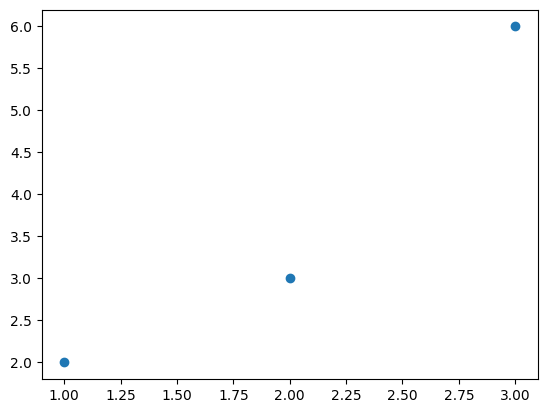

In [72]:
plt.scatter(x_train, y_train)
print(x_train.shape, y_train.shape)

<Axes: title={'center': 'A nice plot'}, xlabel='$x$', ylabel='$y$'>

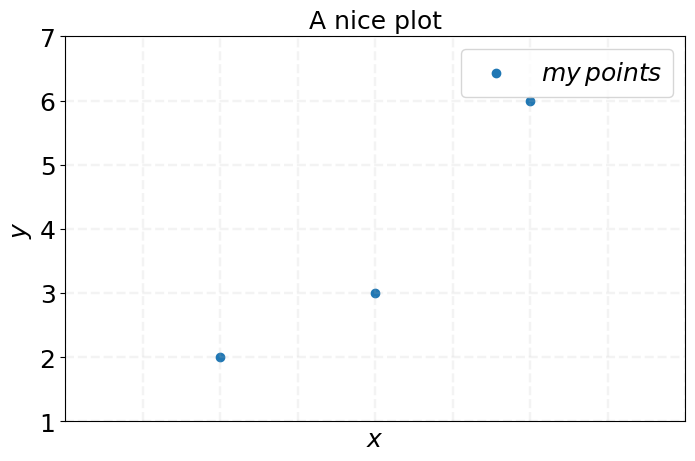

In [76]:
def nice_scatter_plot(x,y,title):
    f_size = 18
    
    fig, ax = plt.subplots(1,1, figsize=(8,5))

    ax.set_xlim(np.min(x)-1, np.max(x) + 1)
    ax.set_ylim(np.min(y)-1, np.max(y) + 1)

    ax.tick_params(labelsize = f_size)

    ax.tick_params(labelbottom=False,  bottom=False)

    ax.set_xlabel(r'$x$', fontsize = f_size)
    ax.set_ylabel(r'$y$', fontsize = f_size)

    ax.set_title(title, fontsize = f_size)

    ax.grid(True, lw=1.75, ls='--', alpha=0.15)

    ax.scatter(x, y, label=r'$my\,points$')
    ax.legend(loc='best', fontsize = f_size);

    return ax

nice_scatter_plot(x_train, y_train, 'A nice plot')


### Building a model from scratch

In [104]:
xx = np.array([[1,2,3],[4,6,8]])
xxx = xx.reshape(-1,2)
xxx.shape

(3, 2)

In [105]:
x_train = x_train.reshape(x_train.shape[0], 1)
y_train = y_train.reshape(y_train.shape[0], 1)

print(x_train.shape)

(3, 1)


In [106]:
y_bar = np.mean(y_train)
x_bar = np.mean(x_train)

numerator = np.sum( (x_train - x_bar)*(y_train - y_bar) )
denominator = np.sum((x_train - x_bar)**2)

print(numerator.shape, denominator.shape)

() ()


In [107]:
a = numerator/denominator

b = y_bar - a * x_bar

print("The best-fit line is {0:3.2f} + {1:3.2f} * x".format(b, a))
print(f'The best fit is {b}')

The best-fit line is 0.67 + 1.00 * x
The best fit is 0.6666666666666665


In [108]:
def simple_linear_regression_fit(x_train: np.ndarray, y_train: np.ndarray) -> np.ndarray:
    """
    Inputs:
    x_train: a (num observations by 1) array holding the values of the predictor variable
    y_train: a (num observations by 1) array holding the values of the response variable

    Returns:
    beta_vals:  a (num_features by 1) array holding the intercept and slope coeficients
    """
    
    # Check input array sizes
    if len(x_train.shape) < 2:
        print("Reshaping features array.")
        x_train = x_train.reshape(x_train.shape[0], 1)

    if len(y_train.shape) < 2:
        print("Reshaping observations array.")
        y_train = y_train.reshape(y_train.shape[0], 1)

    # first, compute means
    y_bar = np.mean(y_train)
    x_bar = np.mean(x_train)

    # build the two terms
    numerator = np.sum( (x_train - x_bar)*(y_train - y_bar) )
    denominator = np.sum((x_train - x_bar)**2)
    
    #slope a
    a = numerator/denominator

    #intercept b
    b = y_bar - a*x_bar

    return np.array([b,a])

In [109]:
x_train = np.array([1 ,2, 3])
y_train = np.array([2, 2, 4])

coeficients = simple_linear_regression_fit(x_train, y_train)

a = coeficients[1]
b = coeficients[0]

print("The best-fit line is {1:8.6f} * x + {0:8.6f}.".format(a, b))

Reshaping features array.
Reshaping observations array.
The best-fit line is 0.666667 * x + 1.000000.


Text(0, 0.5, '$y$')

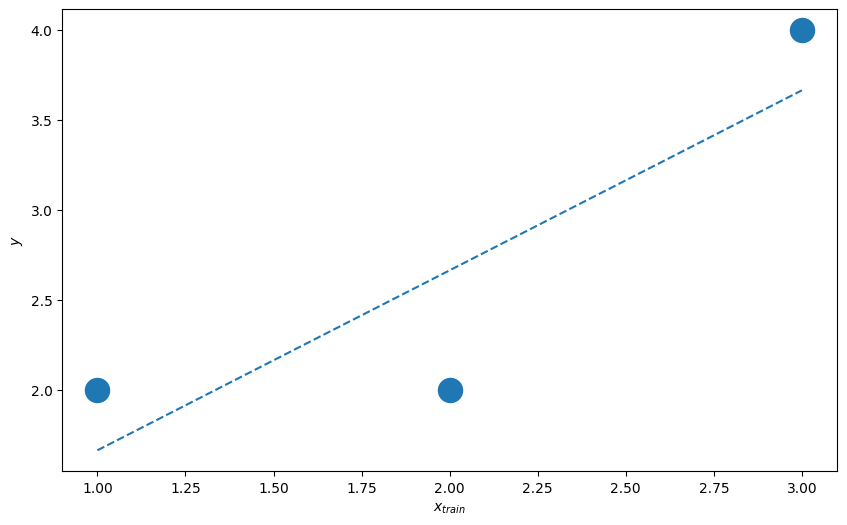

In [110]:
fig_scat, ax_scat = plt.subplots(1,1, figsize=(10,6))

x_train = np.array([[1, 2, 3]]).T

best_fit = b + a * x_train

ax_scat.scatter(x_train, y_train, s=300, label='Training Data')
ax_scat.plot(x_train, best_fit, ls='--', label='Best Fit Line')

ax_scat.set_xlabel(r'$x_{train}$')
ax_scat.set_ylabel(r'$y$')


### Building a model with statsmodels and sklearn

In [111]:
import statsmodels.api as sm

In [112]:
X = sm.add_constant(x_train)

print(X)

toyregr_sm = sm.OLS(y_train, X)

results_sm = toyregr_sm.fit()

beta0_sm = results_sm.params[0]
beta1_sm = results_sm.params[1]

print(f'The regression coef from statsmodels are: beta_0 = {beta0_sm:8.6f} and beta_1 = {beta1_sm:8.6f}')

[[1. 1.]
 [1. 2.]
 [1. 3.]]
The regression coef from statsmodels are: beta_0 = 0.666667 and beta_1 = 1.000000


In [113]:
import warnings

warnings.filterwarnings('ignore')
print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     3.000
Date:                Sun, 08 Mar 2026   Prob (F-statistic):              0.333
Time:                        20:03:25   Log-Likelihood:                -2.0007
No. Observations:                   3   AIC:                             8.001
Df Residuals:                       1   BIC:                             6.199
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6667      1.247      0.535      0.6

In [114]:
from sklearn import linear_model

In [115]:
toyregr = linear_model.LinearRegression()

results = toyregr.fit(x_train, y_train)

beta0_skl = results.intercept_
beta1_skl = results.coef_[0]

print("The regression coefficients from the sklearn package are: beta_0 = {0:8.6f} and beta_1 = {1:8.6f}".format(beta0_skl, beta1_skl))

The regression coefficients from the sklearn package are: beta_0 = 0.666667 and beta_1 = 1.000000


### The scikit-learn library and the shape of things

In [168]:
df = pd.read_csv('Salary_dataset.csv')

In [169]:
print(df.head())

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


In [170]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

print(df.head())
X = np.array(df['YearsExperience'])
Y  = np.array(df["Salary"])

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.25, random_state=0)

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


In [171]:
X_train

array([ 5.4,  8. ,  3. ,  5.2,  3.3,  4.6,  8.3,  6.9,  1.4, 10.6,  3.1,
        2.3,  6. ,  6.1,  3.8,  3.3,  9.1,  2.1,  1.2,  7.2,  5. ,  4.1])

In [172]:
Y_train

array([ 83089., 101303.,  56643.,  66030.,  64446.,  61112., 113813.,
        91739.,  46206., 121873.,  60151.,  39892.,  81364.,  93941.,
        57190.,  54446., 105583.,  43526.,  39344.,  98274.,  67939.,
        56958.])

In [173]:
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

lr = LinearRegression().fit(X_train, Y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, Y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, Y_test):.2f}")

Linear Regression-Training set score: 0.94
Linear Regression-Test set score: 0.98


In [174]:
a = lr.coef_[0]
b = lr.intercept_

print(a, "* x +", b, "= y")

9379.710491946016 * x + 26049.720267542645 = y


In [175]:
lr.predict([[20]])

array([213643.93010646])

In [176]:
a * 20 + b

np.float64(213643.93010646297)

Text(0, 0.5, '$y$')

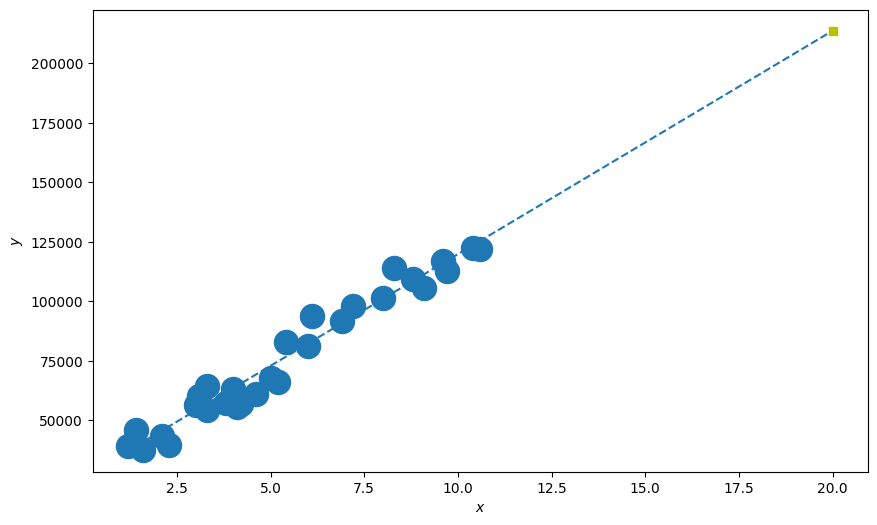

In [177]:
pred = lr.predict([[20]])
fig_scat, ax_scat = plt.subplots(1,1, figsize=(10,6))


x = X.T

best_fit = b + a * (np.append(x, [20]))

ax_scat.scatter(X, Y, s=300, label='Training Data')
ax_scat.plot(np.append(x,[20]), best_fit, ls='--', label='Best Fit Line')

ax_scat.plot([20],pred, "ys", label="LinearRegression")
ax_scat.set_xlabel(r'$x$')
ax_scat.set_ylabel(r'$y$')

### Exercise 2

In [181]:
df = pd.read_csv("score_updated.csv")

In [182]:
print(df.head())

   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30


In [183]:
print(df.head())

X = np.array(df["Hours"])
Y = np.array(df["Scores"])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=0)

   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30


In [184]:
X_train

array([4.1, 1.3, 9.2, 8. , 2.6, 1.2, 7.6, 8.6, 5. , 5.8, 7.9, 5.8, 6.1,
       8.4, 2.1, 3. , 5.1, 9.3, 6.7, 9.4, 3.5, 8.9, 1.9, 1.8, 5.3, 1.5,
       2. , 6.4, 2.5, 3.9, 2.3, 2.8, 5.9, 2.2, 6.9, 6.6, 7.7, 9. , 7. ,
       1.7, 9.7, 6.2, 1. , 1.1, 2.9, 7.4, 4.7, 5.7, 6.1, 3.7, 7.5, 2.7,
       9.8, 8.7, 4.9, 4.2, 6.3, 8. , 4.4, 8.2, 5.2, 4.5, 4.3, 7.1, 4.8,
       6. , 2.7, 4.4, 9.6, 5.4, 3.1, 7.3])

In [185]:
Y_train

array([44, 16, 88, 84, 32, 14, 78, 89, 52, 60, 80, 63, 67, 84, 20, 27, 47,
       94, 71, 93, 30, 95, 24, 21, 56, 20, 18, 64, 21, 38, 23, 29, 62, 22,
       76, 72, 85, 92, 73, 18, 96, 68, 12, 17, 31, 69, 50, 59, 63, 37, 70,
       30, 99, 87, 51, 49, 66, 79, 45, 83, 53, 41, 43, 73, 54, 61, 25, 44,
       98, 55, 28, 77])

In [186]:
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

lr = LinearRegression().fit(X_train, Y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, Y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, Y_test):.2f}")

Linear Regression-Training set score: 0.99
Linear Regression-Test set score: 0.96


In [187]:
def predict_score(lr, hours):
    a = lr.coef_[0]
    b = lr.intercept_

    pred = lr.predict([[hours]])[0]
    print(f"For {hours} hours studied, the predicted score is: {pred:.2f}")

    fig_scat, ax_scat = plt.subplots(1, 1, figsize=(10, 6))

    x = X.T

    best_fit = b + a * np.append(x, [hours])

    ax_scat.scatter(x, Y, s=300, label='Training Data')
    ax_scat.plot(np.append(x, [hours]), best_fit, ls='--', label='Best Fit Line')

    ax_scat.plot([hours], [pred], "ys", label="LinearRegression")
    ax_scat.set_xlabel("Hours")
    ax_scat.set_ylabel("Scores")

For 2.4 hours studied, the predicted score is: 25.47
For 6 hours studied, the predicted score is: 61.52
For 5.6 hours studied, the predicted score is: 57.52


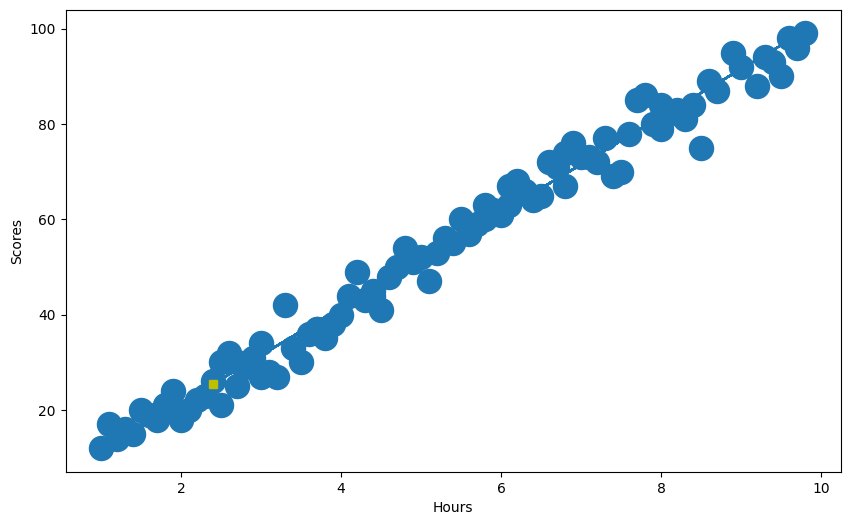

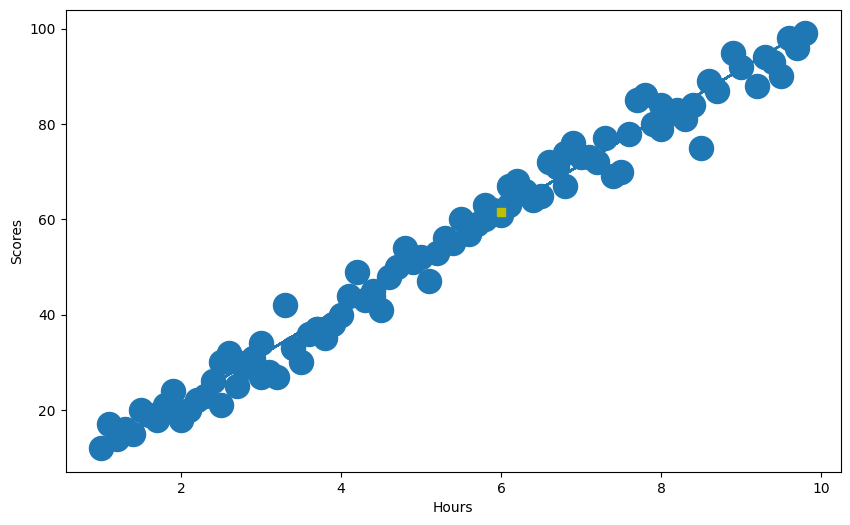

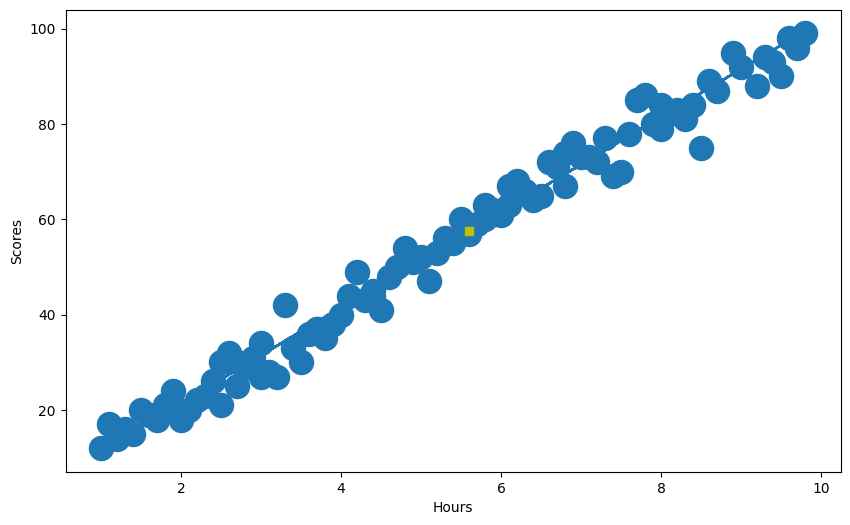

In [189]:
predict_score(lr, 2.4)
predict_score(lr, 6)
predict_score(lr, 5.6)

# 3. Regularisation
### L2 regularisation

In [178]:
from sklearn.linear_model import Ridge

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

ridge = Ridge(alpha=0.7).fit(X_train, Y_train)

print(f"Ridge Regression-Training set score: {ridge.score(X_train, Y_train):.2f}")
print(f"Ridge Regression-Test set score: {ridge.score(X_test, Y_test):.2f}")

Ridge Regression-Training set score: 0.94
Ridge Regression-Test set score: 0.98


### L1 regularization

In [179]:
from sklearn.linear_model import Lasso

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

lasso = Lasso(alpha=1.0).fit(X_train, Y_train)

print(f"Lasso Regression-Training set score: {lasso.score(X_train, Y_train):.2f}")
print(f"Lasso Regression-Test set score: {lasso.score(X_test, Y_test):.2f}")

Lasso Regression-Training set score: 0.94
Lasso Regression-Test set score: 0.98


### Elastic net

In [180]:
from sklearn.linear_model import ElasticNet

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.01).fit(X_train, Y_train)

print(f"Elastic Net-Training set score: {elastic_net.score(X_train, Y_train):.2f}")
print(f"Elastic Net-Test set score: {elastic_net.score(X_test, Y_test):.2f}")

Elastic Net-Training set score: 0.94
Elastic Net-Test set score: 0.98


### Exersise 3

In [192]:
from sklearn.linear_model import Ridge

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

ridge = Ridge(alpha=0.7).fit(X_train, Y_train)

print(f"Ridge Regression-Training set score: {ridge.score(X_train, Y_train):.2f}")
print(f"Ridge Regression-Test set score: {ridge.score(X_test, Y_test):.2f}")

Ridge Regression-Training set score: 0.99
Ridge Regression-Test set score: 0.97


In [190]:
from sklearn.linear_model import Lasso

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

lasso = Lasso(alpha=1.0).fit(X_train, Y_train)

print(f"Lasso Regression-Training set score: {lasso.score(X_train, Y_train):.2f}")
print(f"Lasso Regression-Test set score: {lasso.score(X_test, Y_test):.2f}")

Lasso Regression-Training set score: 0.99
Lasso Regression-Test set score: 0.97


In [191]:
from sklearn.linear_model import ElasticNet

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.01).fit(X_train, Y_train)

print(f"Elastic Net-Training set score: {elastic_net.score(X_train, Y_train):.2f}")
print(f"Elastic Net-Test set score: {elastic_net.score(X_test, Y_test):.2f}")

Elastic Net-Training set score: 0.99
Elastic Net-Test set score: 0.97
